<a href="https://colab.research.google.com/github/AlesioRios/Laboratorio-de-Datos-II/blob/main/Lab_de_Datos_II_TP1_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

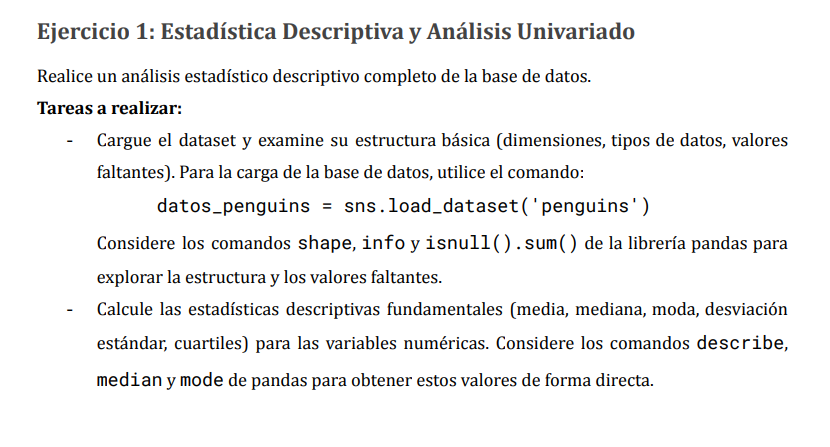

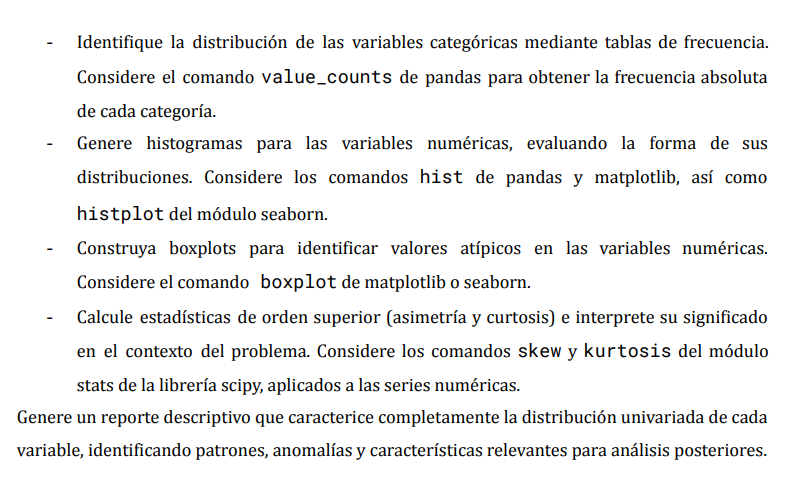

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.00

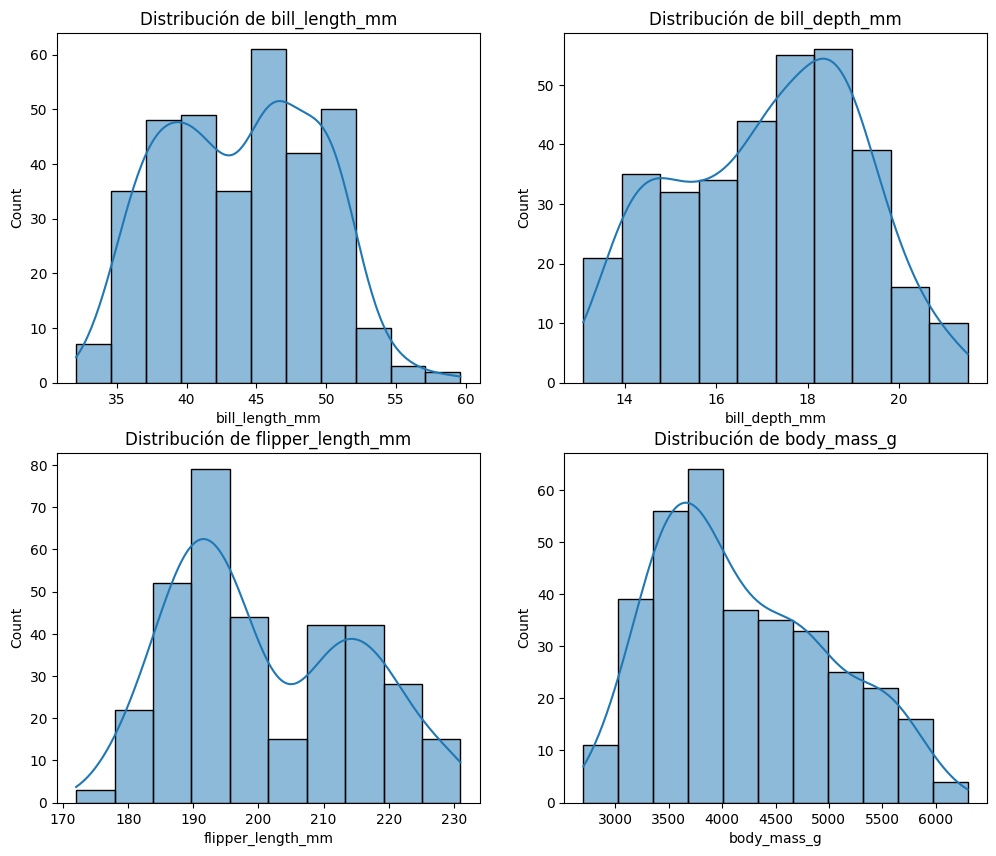

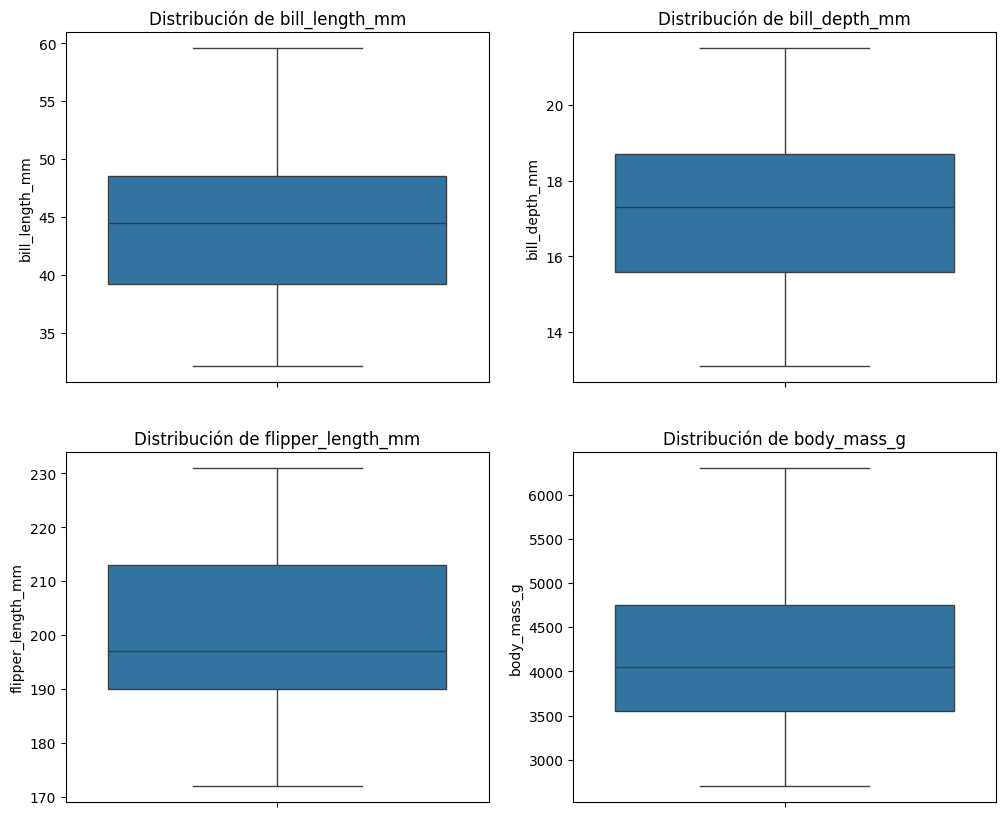

In [ ]:
datos_pinguinos = sns.load_dataset('penguins')
#Uso de .shape, .info(), isnull().sum()
datos_pinguinos.shape
datos_pinguinos.info()
datos_pinguinos.isnull().sum()

print("\n")
#Cálculo de características de estadística descriptiva
estadisticos_principales = datos_pinguinos.describe()
print(estadisticos_principales)
print("\n")
mediana_features = datos_pinguinos.median(axis=0, numeric_only=True)
moda_features = datos_pinguinos.mode(axis=0, numeric_only=True)
print(f"Mediana de las features: {mediana_features}")
print("\n")
print(f"Moda de las features: {moda_features}")

print("\n")
#Análisis de las variables categóricas
freq_species = datos_pinguinos['species'].value_counts()
freq_sex = datos_pinguinos['sex'].value_counts()
freq_island = datos_pinguinos['island'].value_counts()

print(f"Cantidad de pinguinos por especie: {freq_species}")
print("\n")
print(f"Cantidad de pinguinos por sexo: {freq_sex}")
print("\n")
print(f"Cantidad de pinguinos por isla: {freq_island}")
print("\n")

#ANÁLISIS DE LAS VARIABLES NUMÉRICAS
fig, axs = plt.subplots(2,2, figsize=(12,10))
variables = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']

for ax, var in zip(axs.flatten(), variables):
  sns.histplot(data=datos_pinguinos,x=var, kde=True, ax=ax)
  ax.set_title(f"Distribución de {var}")

fig2, axs2 = plt.subplots(2,2, figsize=(12,10))
for ax, var in zip(axs2.flatten(), variables):
  sns.boxplot(data=datos_pinguinos,y=var,ax=ax)
  ax.set_title(f"Distribución de {var}")
print("\n")
for var in variables:
  datos = datos_pinguinos[var].dropna()
  skewness = skew(datos)
  curtosis = kurtosis(datos)
  print(f"Asimetría de la feature {var}: {skewness:.2f}. Curtosis: {curtosis:.2f}")


#CONCLUSIONES SOBRE LOS DATOS
#Las frecuencias absolutas de especie e isla están desbalanceadas. Hay pocos individuos de la especie Chinstrap comparado contra las otras dos especies.
#Existen pocos individuos en la isla Torgesen en comparación a los hallados en las otras islas. Esto podría deberse, bien a que existen efectivamente
#menos pinguinos en esta isla, o porque se muestreó más en las otras islas.

#Existen pocos datos nulos. Sexo es la que más tiene, pero son solamente 11 (menor al 5% del tamaño del dataset).
#En cuanto a las variables numéricas, podemos observar que ninguna distribución se asemeja a una gaussiana.
#La longitud de pico y de aleta parecieran ser bimodales.
#La masa parece tener una asimetría hacia la derecha.
#El espesor de pico presenta una distribución más "rara", con concentración de frecuencia alrededor de 14 a 18.

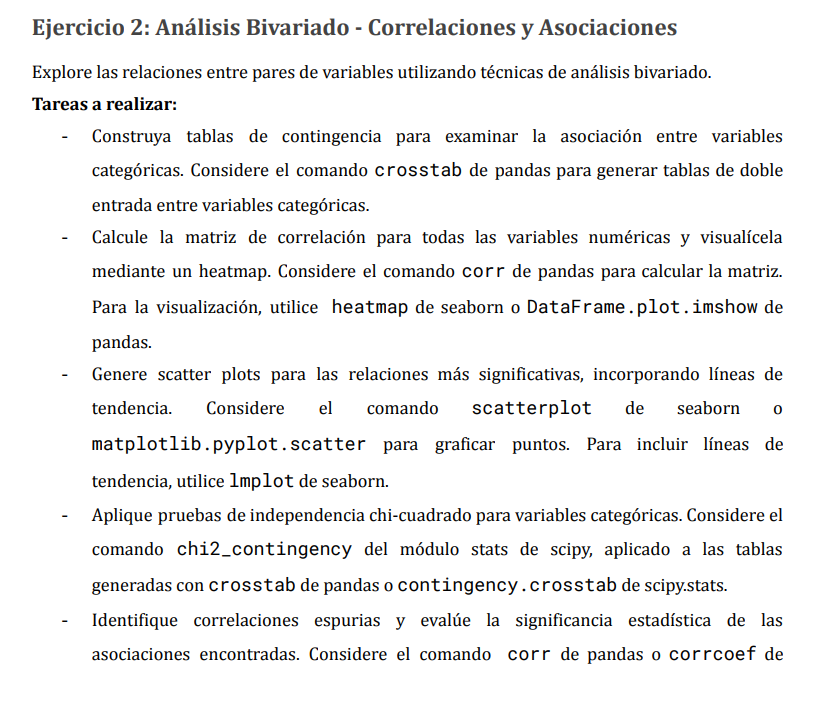

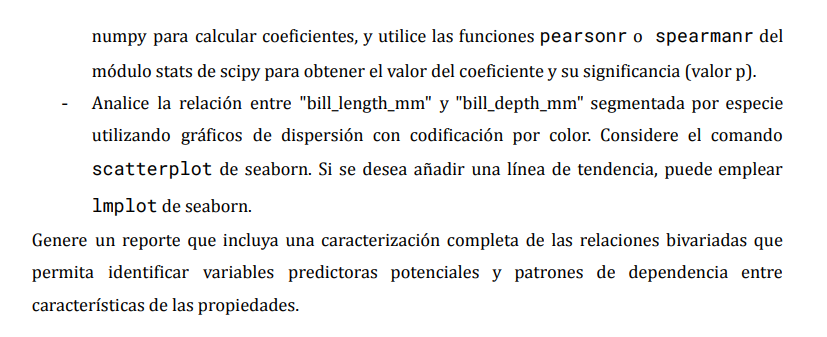

Tabla de contingencia entre escpecie e isla
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


Tabla de contingencia entre escpecie y sexo
species  Adelie  Chinstrap  Gentoo
sex                               
Female       73         34      58
Male         73         34      61


Tabla de contingencia entre sexo e isla
island  Biscoe  Dream  Torgersen
sex                             
Female      80     61         24
Male        83     62         23


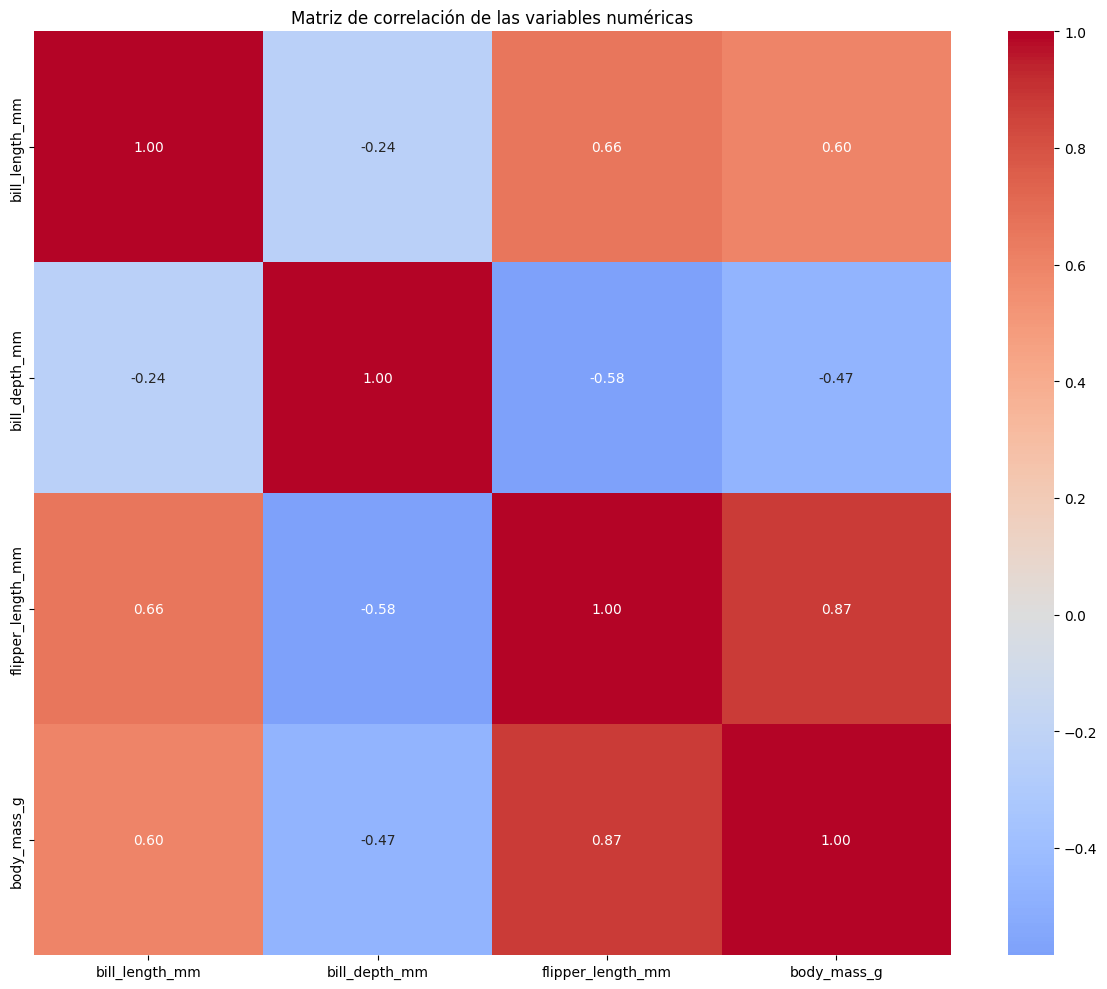

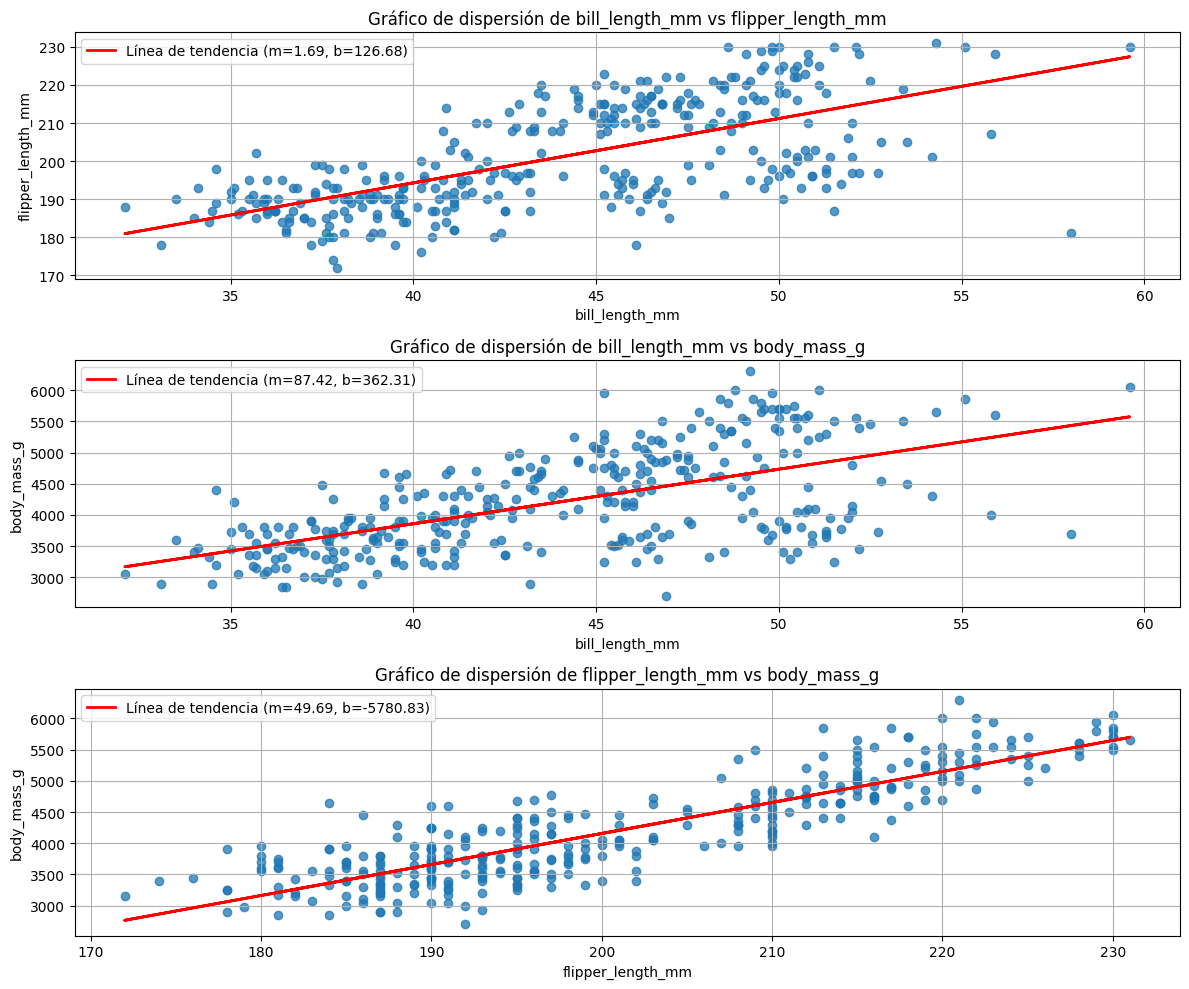

In [ ]:
#Construya tablas de contingencia para examinar la asociación entre variables
#categóricas. Considere el comando crosstab de pandas para generar tablas de doble
#entrada entre variables categóricas.

print("Tabla de contingencia entre escpecie e isla")
tabla_contingencia_especie_isla = pd.crosstab(datos_pinguinos['species'],datos_pinguinos['island'])
print(tabla_contingencia_especie_isla)
print("\n")
print("Tabla de contingencia entre escpecie y sexo")
tabla_contingencia_especie_sexo = pd.crosstab(datos_pinguinos['sex'],datos_pinguinos['species'])
print(tabla_contingencia_especie_sexo)
print("\n")
print("Tabla de contingencia entre sexo e isla")
tabla_contingencia_sexo_isla = pd.crosstab(datos_pinguinos['sex'],datos_pinguinos['island'])
print(tabla_contingencia_sexo_isla)

#Calcule la matriz de correlación para todas las variables numéricas y visualícela
#mediante un heatmap. Considere el comando corr de pandas para calcular la matriz.
#Para la visualización, utilice heatmap de seaborn o DataFrame.plot.imshow de
#pandas.
matriz_correlacion_numericas = datos_pinguinos.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(matriz_correlacion_numericas, annot=True,cmap='coolwarm', center=0, fmt='.2f')
plt.title("Matriz de correlación de las variables numéricas")
plt.tight_layout()
plt.show()

#Genere scatter plots para las relaciones más significativas, incorporando líneas de
#tendencia. Considere el comando scatterplot de seaborn o
#matplotlib.pyplot.scatter para graficar puntos. Para incluir líneas de
#tendencia, utilice lmplot de seaborn.
pares_ploteados = [['bill_length_mm', 'flipper_length_mm'], ['bill_length_mm', 'body_mass_g'],['flipper_length_mm', 'body_mass_g']]
cantidad_pares = len(pares_ploteados)

fig3, axs3 = plt.subplots(cantidad_pares,1, figsize=(12,10))
for i, par in enumerate(pares_ploteados):
  x, y = datos_pinguinos[par[0]].dropna(), datos_pinguinos[par[1]].dropna()
  m, b = np.polyfit(x,y,1)
  axs3[i].scatter(x, y, alpha=0.75)
  axs3[i].plot(x, m*x+b, linewidth=2.0, color='red', label=f"Línea de tendencia (m={m:.2f}, b={b:.2f})")
  axs3[i].set_xlabel(f"{par[0]}")
  axs3[i].set_ylabel(f"{par[1]}")
  axs3[i].set_title(f"Gráfico de dispersión de {par[0]} vs {par[1]}")
  axs3[i].grid()
  axs3[i].legend()

plt.tight_layout()
plt.show()
